# Métriques de qualité de GSE149689

Exploration descriptive des métriques QC, sans filtrage ni transformation des données.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc

## Chargement et reconstruction des métadonnées

In [2]:
adata = sc.read_h5ad("../data/processed/GSE149689_raw.h5ad")
figure_dir = Path("../results/figures/qc")
figure_dir.mkdir(parents=True, exist_ok=True)

In [3]:
barcode_suffix = adata.obs_names.to_series(index=adata.obs_names).str.extract(
    r"-(\d+)$", expand=False
)
if barcode_suffix.isna().any():
    raise ValueError("Au moins un barcode ne possède pas de suffixe numérique.")
adata.obs["sample_id"] = "Sample" + barcode_suffix.astype(int).astype(str)

In [4]:
sample_metadata = pd.DataFrame(
    [
        ("Sample1", "SW103", "COVID-19", "severe"),
        ("Sample2", "SW104", "COVID-19", "mild"),
        ("Sample3", "SW105", "influenza", "severe"),
        ("Sample4", "SW106", "influenza", "severe"),
        ("Sample5", "SW107", "healthy_control", pd.NA),
        ("Sample6", "SW108", "influenza", "severe"),
        ("Sample7", "SW109", "influenza", "severe"),
        ("Sample8", "SW110", "influenza", "severe"),
        ("Sample9", "SW111", "COVID-19", "severe"),
        ("Sample10", "SW112", "COVID-19", "severe"),
        ("Sample11", "SW113", "COVID-19", "mild"),
        ("Sample12", "SW114", "COVID-19", "mild"),
        ("Sample13", "SW115", "healthy_control", pd.NA),
        ("Sample14", "SW116", "healthy_control", pd.NA),
        ("Sample15", "SW117", "COVID-19", "severe"),
        ("Sample16", "SW118", "COVID-19", "severe"),
        ("Sample17", "SW119", "COVID-19", "severe"),
        ("Sample18", "SW120", "COVID-19", "mild"),
        ("Sample19", "SW121", "healthy_control", pd.NA),
        ("Sample20", "SW122", "COVID-19", "asymptomatic"),
    ],
    columns=["sample_id", "subject_id", "disease", "severity"],
)
adata.obs = adata.obs.join(
    sample_metadata.set_index("sample_id"),
    on="sample_id",
    validate="many_to_one",
)

## 1. Identification des gènes mitochondriaux

In [5]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
adata.var["mt"] = adata.var["mt"].to_numpy(dtype=bool)
mt_gene_names = adata.var_names[adata.var["mt"]]
print("Nombre de gènes mitochondriaux :", len(mt_gene_names))
print("10 premiers gènes mitochondriaux :", mt_gene_names[:10].tolist())
if len(mt_gene_names) < 10:
    raise RuntimeError("Moins de 10 gènes préfixés MT- ont été détectés ; analyse QC arrêtée.")

Nombre de gènes mitochondriaux : 13
10 premiers gènes mitochondriaux : ['MT-ND1', 'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP8', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND4L', 'MT-ND4']


## 2. Calcul des métriques QC

In [6]:
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    percent_top=None,
    log1p=False,
    inplace=True,
)

## 3. Nouvelles colonnes et statistiques descriptives

In [7]:
qc_columns = [
    "total_counts",
    "n_genes_by_counts",
    "total_counts_mt",
    "pct_counts_mt",
]
print(adata.obs[qc_columns].columns.tolist())
display(
    adata.obs[["total_counts", "n_genes_by_counts", "pct_counts_mt"]].describe()
)

['total_counts', 'n_genes_by_counts', 'total_counts_mt', 'pct_counts_mt']


,total_counts,n_genes_by_counts,pct_counts_mt
count,85144.000000,85144.000000,85144.000000
mean,5407.850586,1492.995713,17.537800
std,5405.562988,1097.417462,22.688229
min,15.000000,8.000000,0.000000
25%,1436.000000,452.000000,5.822852
50%,4504.000000,1522.000000,8.104242
75%,6905.000000,2084.000000,14.800206
max,152409.000000,8212.000000,99.813255


## 4. Distributions globales

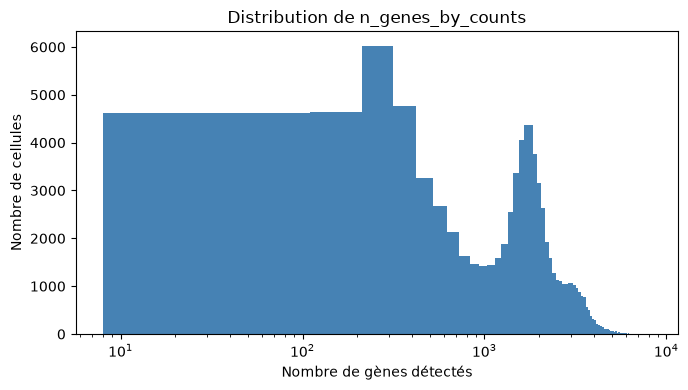

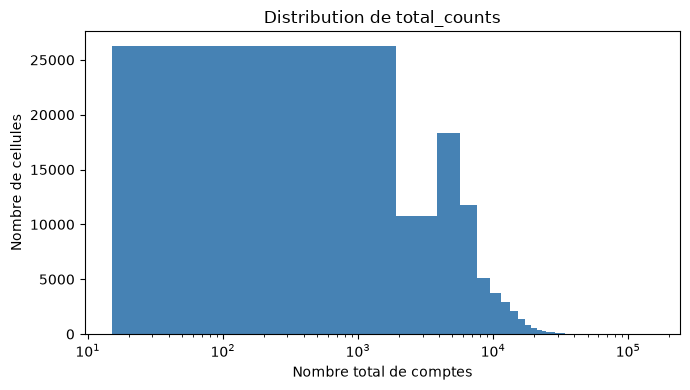

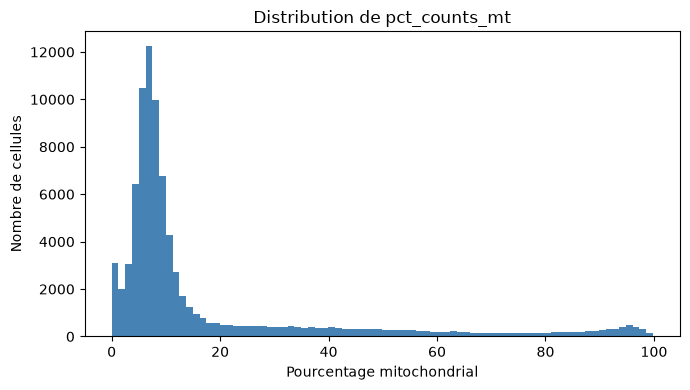

In [8]:
histogram_specs = [
    ("n_genes_by_counts", "Nombre de gènes détectés", "log"),
    ("total_counts", "Nombre total de comptes", "log"),
    ("pct_counts_mt", "Pourcentage mitochondrial", "linear"),
]
for metric, label, xscale in histogram_specs:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(adata.obs[metric], bins=80, color="steelblue", edgecolor="none")
    ax.set_xlabel(label)
    ax.set_ylabel("Nombre de cellules")
    ax.set_title(f"Distribution de {metric}")
    ax.set_xscale(xscale)
    fig.tight_layout()
    fig.savefig(figure_dir / f"hist_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()

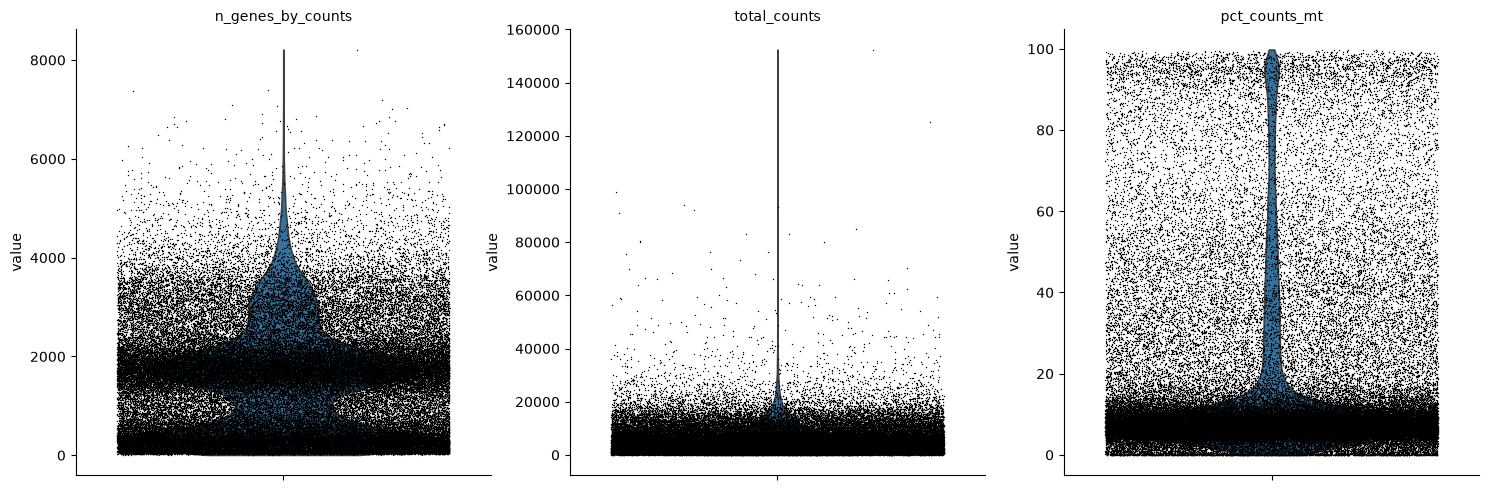

In [9]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
    show=False,
)
plt.gcf().savefig(figure_dir / "violin_global_qc.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Relations entre métriques

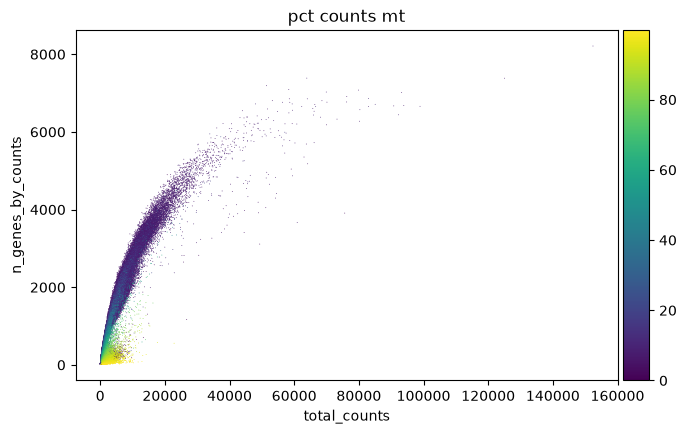

In [10]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="n_genes_by_counts",
    color="pct_counts_mt",
    show=False,
)
plt.gcf().savefig(figure_dir / "scatter_counts_genes_mt.png", dpi=150, bbox_inches="tight")
plt.show()

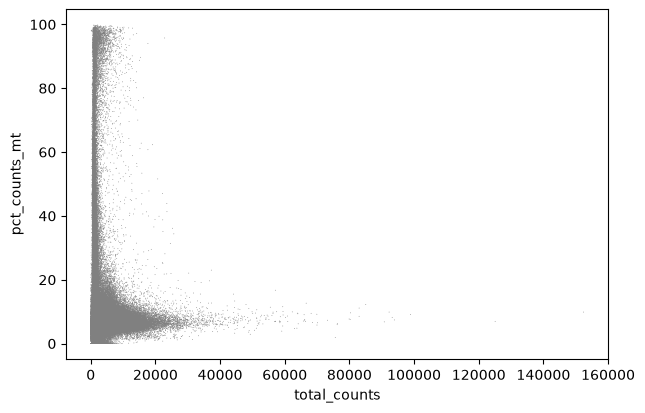

In [11]:
sc.pl.scatter(
    adata,
    x="total_counts",
    y="pct_counts_mt",
    show=False,
)
plt.gcf().savefig(figure_dir / "scatter_counts_mt.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. QC par échantillon

In [12]:
qc_metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
aggregations = {"n_cells": ("total_counts", "size")}
for metric in qc_metrics:
    aggregations[f"{metric}_median"] = (metric, "median")
    for label, quantile in [("q05", 0.05), ("q25", 0.25), ("q75", 0.75), ("q95", 0.95)]:
        aggregations[f"{metric}_{label}"] = (
            metric, lambda values, q=quantile: values.quantile(q)
        )

qc_by_sample = (
    adata.obs.groupby("sample_id", observed=True)
    .agg(**aggregations)
    .reindex(sample_metadata["sample_id"])
)
display(qc_by_sample)

,n_cells,n_genes_by_counts_median,n_genes_by_counts_q05,n_genes_by_counts_q25,n_genes_by_counts_q75,n_genes_by_counts_q95,total_counts_median,total_counts_q05,total_counts_q25,total_counts_q75,total_counts_q95,pct_counts_mt_median,pct_counts_mt_q05,pct_counts_mt_q25,pct_counts_mt_q75,pct_counts_mt_q95
sample_id,,,,,,,,,,,,,,,,
Sample1,6455,1146.0,102.00,267.00,1967.50,3312.00,3571.0,496.00,1071.50,7183.00,13947.60,7.915150,1.413825,5.618163,12.651303,83.364788
Sample2,7731,1409.0,238.50,554.00,1753.00,3013.00,4576.0,659.00,1401.00,6147.50,12678.00,10.004359,4.869808,7.170594,27.708274,58.419785
Sample3,5851,1967.0,100.50,1127.50,2471.00,3634.00,5965.0,771.00,2859.50,8637.00,16532.50,8.100208,4.300071,6.646296,10.471442,89.016994
Sample4,1724,1262.5,50.00,741.75,1664.00,2801.80,3627.0,363.90,1827.00,5496.25,10947.70,8.974206,0.961538,7.097246,11.663757,23.965633
Sample5,6426,1669.5,148.00,561.00,1969.00,3142.50,4979.5,701.00,1471.00,6306.50,12292.50,9.275319,5.137861,7.239730,31.107967,76.486835
Sample6,3516,1762.0,68.00,851.50,2242.00,3520.00,4793.0,612.75,2256.75,6863.00,13756.75,9.220806,2.236151,6.938571,13.520237,90.604536
Sample7,1455,1650.0,49.70,597.50,2228.50,3536.60,4672.0,206.60,1699.00,6995.00,14974.70,7.521428,0.273685,5.392504,10.993280,80.813212
Sample8,2001,120.0,25.00,53.00,339.00,1883.00,1167.0,126.00,684.00,2640.00,5455.00,0.433168,0.000000,0.033591,6.250000,34.551495
Sample9,538,954.5,22.85,209.75,1772.00,3176.05,2136.0,33.00,621.00,4640.00,11654.00,4.486781,0.588684,2.796402,7.930457,96.884030


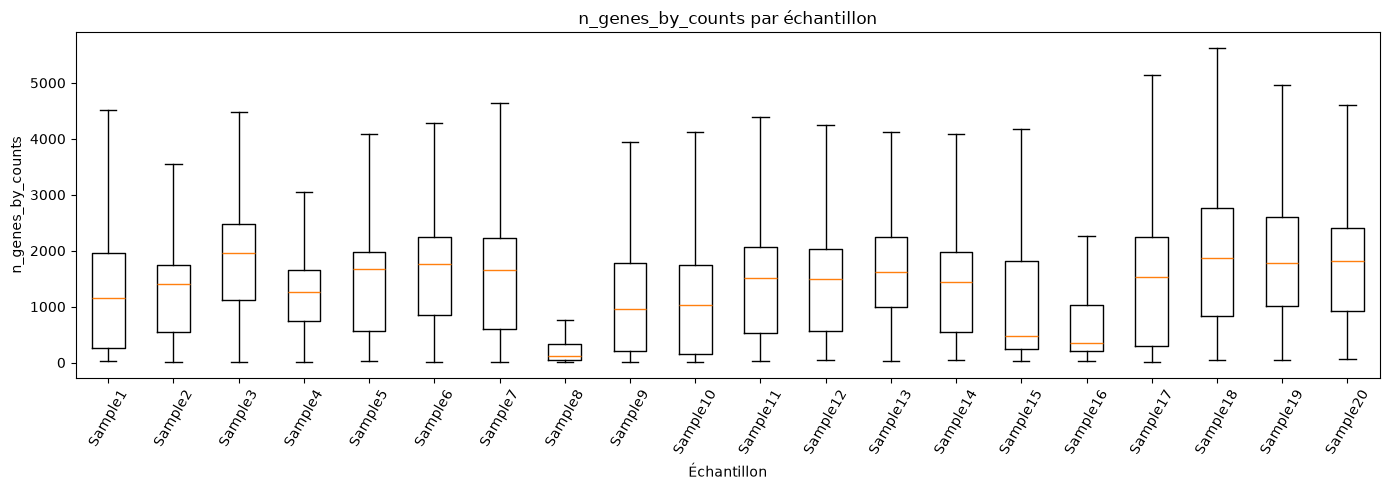

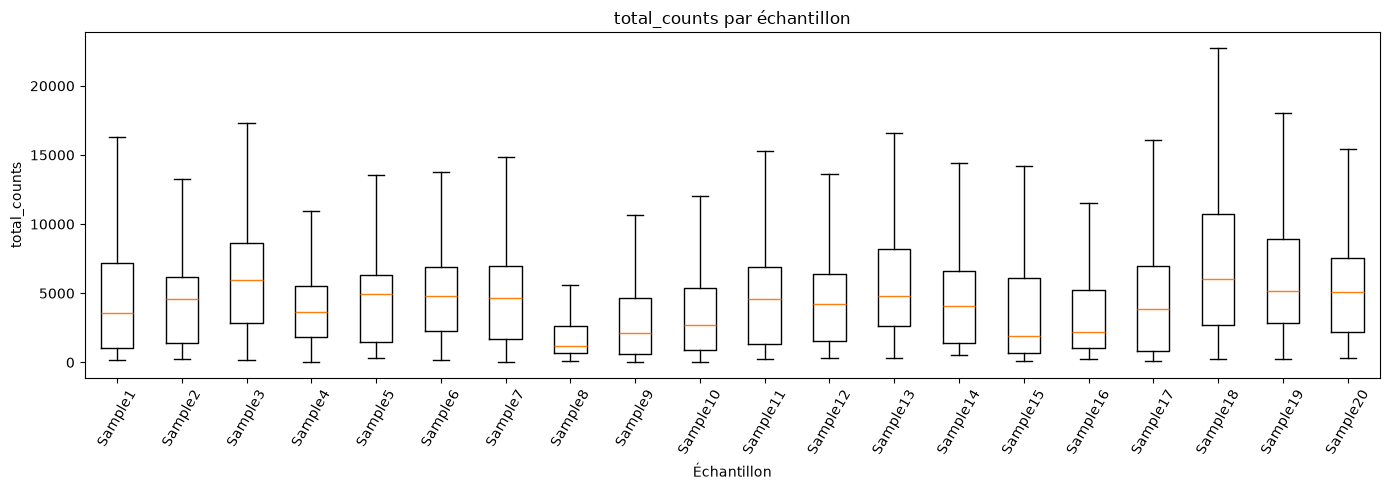

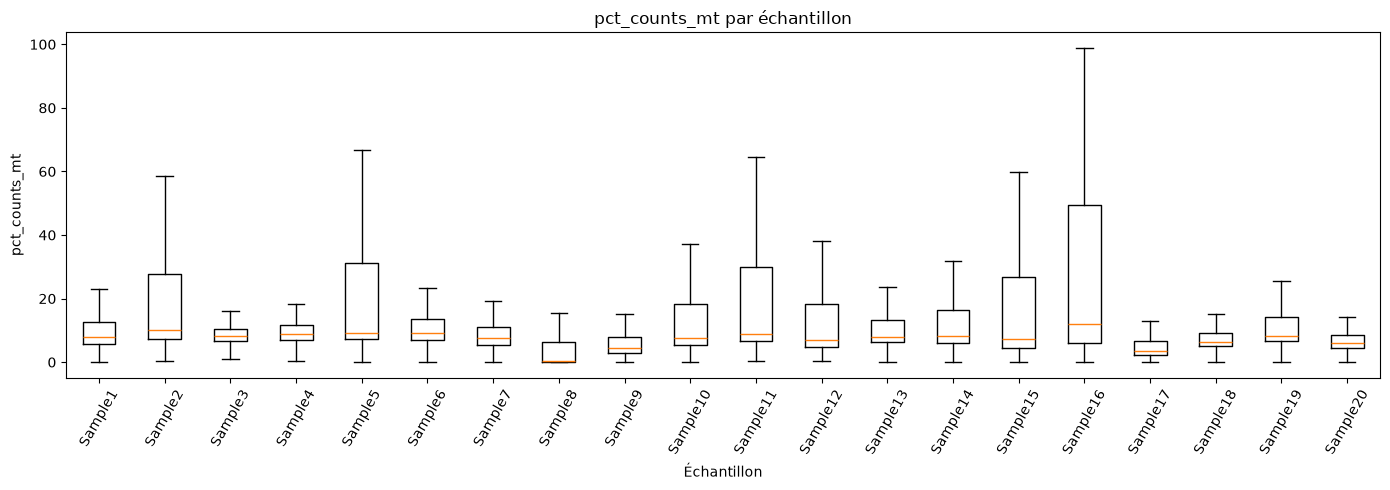

In [13]:
sample_order = sample_metadata["sample_id"].tolist()
for metric in qc_metrics:
    grouped_values = [
        adata.obs.loc[adata.obs["sample_id"] == sample_id, metric]
        for sample_id in sample_order
    ]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.boxplot(grouped_values, tick_labels=sample_order, showfliers=False)
    ax.set_xlabel("Échantillon")
    ax.set_ylabel(metric)
    ax.set_title(f"{metric} par échantillon")
    ax.tick_params(axis="x", rotation=60)
    fig.tight_layout()
    fig.savefig(figure_dir / f"boxplot_{metric}_by_sample.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Contrôles de validité

In [14]:
checks = {
    "total_counts_nonnegative": bool((adata.obs["total_counts"] >= 0).all()),
    "n_genes_by_counts_nonnegative": bool((adata.obs["n_genes_by_counts"] >= 0).all()),
    "pct_counts_mt_in_0_100": bool(adata.obs["pct_counts_mt"].between(0, 100).all()),
    "no_missing_main_qc_metrics": not adata.obs[qc_metrics].isna().any().any(),
}
if not all(checks.values()):
    raise AssertionError({name: passed for name, passed in checks.items() if not passed})
print("Contrôles :", ", ".join(f"{name}=OK" for name in checks))

Contrôles : total_counts_nonnegative=OK, n_genes_by_counts_nonnegative=OK, pct_counts_mt_in_0_100=OK, no_missing_main_qc_metrics=OK


## Résumé descriptif

In [15]:
global_summary = adata.obs[qc_metrics].quantile([0.05, 0.25, 0.5, 0.75, 0.95])
print("Résumé descriptif global (quantiles 5 %, 25 %, 50 %, 75 % et 95 %) :")
display(global_summary)
print("Étendue des médianes entre échantillons :")
for metric in qc_metrics:
    medians = qc_by_sample[f"{metric}_median"]
    print(f"- {metric}: {medians.min():.2f} à {medians.max():.2f}")
print("Ces distributions sont décrites sans appliquer ni proposer de seuil de filtrage.")

Résumé descriptif global (quantiles 5 %, 25 %, 50 %, 75 % et 95 %) :


,n_genes_by_counts,total_counts,pct_counts_mt
0.05,103.0,542.00,2.001689
0.25,452.0,1436.00,5.822852
0.50,1522.0,4504.00,8.104242
0.75,2084.0,6905.00,14.800206
0.95,3509.0,15206.85,79.423769


Étendue des médianes entre échantillons :
- n_genes_by_counts: 120.00 à 1967.00
- total_counts: 1167.00 à 6004.00
- pct_counts_mt: 0.43 à 12.10
Ces distributions sont décrites sans appliquer ni proposer de seuil de filtrage.


## Impact of candidate QC thresholds

Évaluation descriptive de seuils candidats au moyen de masques.

In [16]:
min_genes = 200
min_counts = 500
max_pct_mt = 20

pass_min_genes = adata.obs["n_genes_by_counts"] >= min_genes
pass_min_counts = adata.obs["total_counts"] >= min_counts
pass_mt = adata.obs["pct_counts_mt"] <= max_pct_mt
pass_qc = pass_min_genes & pass_min_counts & pass_mt

In [17]:
n_total = adata.n_obs
criterion_impact = pd.DataFrame(
    {
        "criterion": ["min_genes", "min_counts", "max_pct_mt"],
        "n_removed": [
            int((~pass_min_genes).sum()),
            int((~pass_min_counts).sum()),
            int((~pass_mt).sum()),
        ],
    }
)
criterion_impact["pct_removed"] = 100 * criterion_impact["n_removed"] / n_total
display(criterion_impact)

n_kept = int(pass_qc.sum())
print(f"Cellules conservées après combinaison : {n_kept:,} / {n_total:,} ({100 * n_kept / n_total:.2f} %)")

,criterion,n_removed,pct_removed
0,min_genes,8615,10.118153
1,min_counts,3431,4.029644
2,max_pct_mt,18279,21.468336


Cellules conservées après combinaison : 60,688 / 85,144 (71.28 %)


In [18]:
threshold_status = pd.DataFrame(
    {
        "sample_id": adata.obs["sample_id"],
        "pass_qc": pass_qc,
        "fail_min_genes": ~pass_min_genes,
        "fail_min_counts": ~pass_min_counts,
        "fail_max_pct_mt": ~pass_mt,
    },
    index=adata.obs_names,
)

thresholds_by_sample = (
    threshold_status.groupby("sample_id", observed=True)
    .agg(
        n_cells_before=("pass_qc", "size"),
        n_cells_after=("pass_qc", "sum"),
        n_fail_min_genes=("fail_min_genes", "sum"),
        n_fail_min_counts=("fail_min_counts", "sum"),
        n_fail_max_pct_mt=("fail_max_pct_mt", "sum"),
    )
)
thresholds_by_sample["n_removed"] = (
    thresholds_by_sample["n_cells_before"] - thresholds_by_sample["n_cells_after"]
)
thresholds_by_sample["pct_removed"] = (
    100 * thresholds_by_sample["n_removed"] / thresholds_by_sample["n_cells_before"]
)
thresholds_by_sample = thresholds_by_sample[
    [
        "n_cells_before", "n_cells_after", "n_removed", "pct_removed",
        "n_fail_min_genes", "n_fail_min_counts", "n_fail_max_pct_mt",
    ]
].sort_values("pct_removed", ascending=False)
display(thresholds_by_sample)

,n_cells_before,n_cells_after,n_removed,pct_removed,n_fail_min_genes,n_fail_min_counts,n_fail_max_pct_mt
sample_id,,,,,,,
Sample8,2001,648,1353,67.616192,1268,341,136
Sample16,4371,1892,2479,56.714711,1062,246,1711
Sample15,2349,1334,1015,43.209877,431,365,630
Sample10,1167,733,434,37.189374,324,197,279
Sample11,6398,4053,2345,36.652079,159,198,2139
Sample9,538,358,180,33.457249,126,120,63
Sample2,7731,5169,2562,33.139309,237,164,2348
Sample5,6426,4450,1976,30.750078,525,67,1842
Sample1,6455,4553,1902,29.465531,1086,342,1108


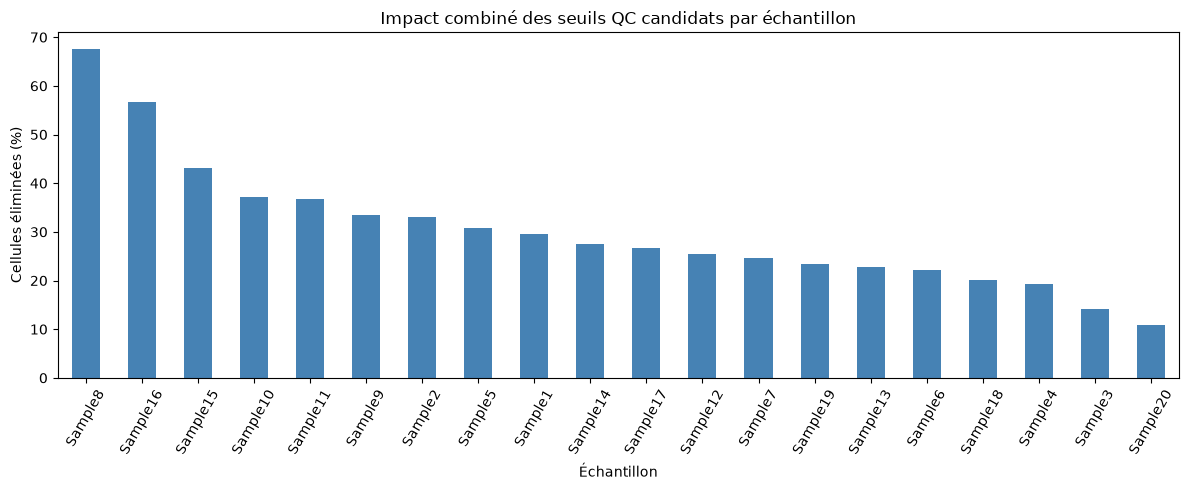

In [19]:
fig, ax = plt.subplots(figsize=(12, 5))
thresholds_by_sample["pct_removed"].plot.bar(ax=ax, color="steelblue")
ax.set_xlabel("Échantillon")
ax.set_ylabel("Cellules éliminées (%)")
ax.set_title("Impact combiné des seuils QC candidats par échantillon")
ax.tick_params(axis="x", rotation=60)
fig.tight_layout()
fig.savefig(figure_dir / "candidate_thresholds_pct_removed_by_sample.png", dpi=150, bbox_inches="tight")
plt.show()

In [20]:
n_failed_criteria = (~pass_min_genes).astype(int) + (~pass_min_counts).astype(int) + (~pass_mt).astype(int)
overlap_masks = {
    "only_min_genes": (~pass_min_genes) & pass_min_counts & pass_mt,
    "only_min_counts": pass_min_genes & (~pass_min_counts) & pass_mt,
    "only_max_pct_mt": pass_min_genes & pass_min_counts & (~pass_mt),
    "multiple_criteria": n_failed_criteria >= 2,
}
overlap_table = pd.DataFrame(
    {
        "failure_category": list(overlap_masks),
        "n_cells": [int(mask.sum()) for mask in overlap_masks.values()],
    }
)
overlap_table["pct_all_cells"] = 100 * overlap_table["n_cells"] / n_total
display(overlap_table)

,failure_category,n_cells,pct_all_cells
0,only_min_genes,3084,3.622099
1,only_min_counts,1638,1.923800
2,only_max_pct_mt,14016,16.461524
3,multiple_criteria,5718,6.715682


In [21]:
n_removed_combined = n_total - n_kept
most_affected_sample = thresholds_by_sample.index[0]
most_affected_pct = thresholds_by_sample.iloc[0]["pct_removed"]
least_affected_sample = thresholds_by_sample.index[-1]
least_affected_pct = thresholds_by_sample.iloc[-1]["pct_removed"]
print(
    f"Impact combiné descriptif : {n_removed_combined:,} cellules ({100 * n_removed_combined / n_total:.2f} %) "
    f"échouent au moins un critère et {n_kept:,} ({100 * n_kept / n_total:.2f} %) les satisfont tous."
)
print(
    f"La proportion éliminée varie de {least_affected_pct:.2f} % ({least_affected_sample}) "
    f"à {most_affected_pct:.2f} % ({most_affected_sample})."
)
print("Ces résultats décrivent uniquement l'impact des seuils candidats, sans décision automatique de les retenir.")

Impact combiné descriptif : 24,456 cellules (28.72 %) échouent au moins un critère et 60,688 (71.28 %) les satisfont tous.
La proportion éliminée varie de 10.78 % (Sample20) à 67.62 % (Sample8).
Ces résultats décrivent uniquement l'impact des seuils candidats, sans décision automatique de les retenir.


## QC threshold sensitivity analysis

Comparaison descriptive de scénarios au moyen de masques temporaires.

In [22]:
qc_scenarios = {
    "lenient": {"min_genes": 100, "min_counts": 300, "max_pct_mt": 30},
    "moderate_mt": {"min_genes": 200, "min_counts": 500, "max_pct_mt": 25},
    "original_paper": {"min_genes": 200, "min_counts": None, "max_pct_mt": 15},
    "balanced": {"min_genes": 200, "min_counts": 500, "max_pct_mt": 20},
    "strict_complexity": {"min_genes": 300, "min_counts": 800, "max_pct_mt": 20},
    "stringent": {"min_genes": 500, "min_counts": 1000, "max_pct_mt": 15},
}
scenario_masks = {
    name: ((adata.obs["n_genes_by_counts"] >= values["min_genes"])
           & (True if values["min_counts"] is None
              else adata.obs["total_counts"] >= values["min_counts"])
           & (adata.obs["pct_counts_mt"] <= values["max_pct_mt"]))
    for name, values in qc_scenarios.items()
}

In [23]:
global_rows = []
for scenario, mask in scenario_masks.items():
    n_before = adata.n_obs
    n_after = int(mask.sum())
    retained = adata.obs.loc[mask, qc_metrics]
    global_rows.append({
        "scenario": scenario, "n_cells_before": n_before, "n_cells_after": n_after,
        "n_removed": n_before - n_after, "pct_removed": 100 * (n_before - n_after) / n_before,
        "pct_retained": 100 * n_after / n_before,
        "median_n_genes_by_counts": retained["n_genes_by_counts"].median(),
        "median_total_counts": retained["total_counts"].median(),
        "median_pct_counts_mt": retained["pct_counts_mt"].median(),
    })
global_sensitivity = pd.DataFrame(global_rows).set_index("scenario")

In [24]:
scenario_order = global_sensitivity.sort_values("pct_retained", ascending=False).index.tolist()
display_scenarios = [
    "lenient", "moderate_mt", "balanced", "original_paper", "stringent",
]
global_sensitivity_ordered = global_sensitivity.reindex(display_scenarios)
display(global_sensitivity_ordered)

,n_cells_before,n_cells_after,n_removed,pct_removed,pct_retained,median_n_genes_by_counts,median_total_counts,median_pct_counts_mt
scenario,,,,,,,,
lenient,85144,67612,17532,20.590999,79.409001,1736.0,5271.0,7.367063
moderate_mt,85144,62420,22724,26.688904,73.311096,1794.0,5514.5,7.352192
balanced,85144,60688,24456,28.723104,71.276896,1811.0,5591.0,7.255962
original_paper,85144,59572,25572,30.033825,69.966175,1812.5,5591.0,7.093283
stringent,85144,53443,31701,37.232218,62.767782,1893.0,5937.0,7.193416


In [25]:
reported_cells_original_study = 59_572
original_paper_cells = int(global_sensitivity.loc["original_paper", "n_cells_after"])
original_paper_difference = original_paper_cells - reported_cells_original_study
original_paper_comparison = pd.DataFrame(
    {
        "quantity": [
            "cells_retained_with_reconstructed_criteria",
            "cells_reported_after_QC_in_original_study",
            "absolute_difference",
        ],
        "n_cells": [original_paper_cells, reported_cells_original_study, original_paper_difference],
    }
)
display(original_paper_comparison)
print(
    "Cette comparaison est descriptive : l'effectif publié peut refléter d'autres étapes ou détails "
    "de traitement non reproduits par ces deux critères seuls."
)

,quantity,n_cells
0,cells_retained_with_reconstructed_criteria,59572
1,cells_reported_after_QC_in_original_study,59572
2,absolute_difference,0


Cette comparaison est descriptive : l'effectif publié peut refléter d'autres étapes ou détails de traitement non reproduits par ces deux critères seuls.


In [26]:
def retention_by_group(group_values, group_name):
    rows = []
    for scenario in scenario_order:
        status = pd.DataFrame(
            {group_name: group_values, "retained": scenario_masks[scenario]},
            index=adata.obs_names,
        )
        summary = (
            status.groupby(group_name, observed=True, dropna=False)["retained"]
            .agg(n_cells_before="size", n_cells_after="sum")
            .reset_index()
        )
        summary["pct_retained"] = 100 * summary["n_cells_after"] / summary["n_cells_before"]
        summary["pct_removed"] = 100 - summary["pct_retained"]
        summary.insert(0, "scenario", scenario)
        rows.append(summary)
    return pd.concat(rows, ignore_index=True)

sample_sensitivity_long = retention_by_group(adata.obs["sample_id"], "sample_id")
disease_sensitivity_long = retention_by_group(adata.obs["disease"], "disease")
severity_available = "severity" in adata.obs.columns
if severity_available:
    severity_values = adata.obs["severity"].astype("string").fillna("not_applicable")
    severity_sensitivity_long = retention_by_group(severity_values, "severity")

In [27]:
sample_retention_matrix = sample_sensitivity_long.pivot(
    index="sample_id", columns="scenario", values="pct_retained"
).reindex(index=sample_order, columns=display_scenarios)
display(sample_sensitivity_long.loc[sample_sensitivity_long["scenario"].isin(display_scenarios)])
display(sample_retention_matrix)
display(disease_sensitivity_long.loc[disease_sensitivity_long["scenario"].isin(display_scenarios)])
if severity_available:
    display(severity_sensitivity_long.loc[severity_sensitivity_long["scenario"].isin(display_scenarios)])

,scenario,sample_id,n_cells_before,n_cells_after,pct_retained,pct_removed
0,lenient,Sample1,6455,5384,83.408211,16.591789
1,lenient,Sample2,7731,5910,76.445479,23.554521
2,lenient,Sample3,5851,5251,89.745343,10.254657
3,lenient,Sample4,1724,1467,85.092807,14.907193
4,lenient,Sample5,6426,4740,73.762838,26.237162
...,...,...,...,...,...,...
115,stringent,Sample16,4371,1037,23.724548,76.275452
116,stringent,Sample17,1755,1139,64.900285,35.099715
117,stringent,Sample18,3984,2950,74.046185,25.953815
118,stringent,Sample19,5542,4001,72.194154,27.805846


scenario,lenient,moderate_mt,balanced,original_paper,stringent
sample_id,,,,,
Sample1,83.408211,72.083656,70.534469,69.155693,54.717273
Sample2,76.445479,70.094425,66.860691,64.661751,60.845945
Sample3,89.745343,86.771492,85.780209,83.660913,80.413605
Sample4,85.092807,82.946636,80.684455,77.204176,73.607889
Sample5,73.762838,70.774977,69.249922,67.398070,65.530657
Sample6,83.987486,80.261661,77.929465,73.976109,69.908987
Sample7,80.343643,76.838488,75.463918,71.477663,68.453608
Sample8,48.375812,33.083458,32.383808,32.583708,17.941029
Sample9,77.509294,67.472119,66.542751,73.977695,58.921933


,scenario,disease,n_cells_before,n_cells_after,pct_retained,pct_removed
0,lenient,COVID-19,45899,36251,78.979934,21.020066
1,lenient,healthy_control,24698,19553,79.168354,20.831646
2,lenient,influenza,14547,11808,81.171376,18.828624
3,moderate_mt,COVID-19,45899,32612,71.051657,28.948343
4,moderate_mt,healthy_control,24698,18699,75.710584,24.289416
5,moderate_mt,influenza,14547,11109,76.366261,23.633739
6,balanced,COVID-19,45899,31584,68.811957,31.188043
7,balanced,healthy_control,24698,18208,73.722569,26.277431
8,balanced,influenza,14547,10896,74.902042,25.097958
9,original_paper,COVID-19,45899,31463,68.548334,31.451666


,scenario,severity,n_cells_before,n_cells_after,pct_retained,pct_removed
0,lenient,asymptomatic,4868,4642,95.357436,4.642564
1,lenient,mild,24396,19195,78.680931,21.319069
2,lenient,not_applicable,24698,19553,79.168354,20.831646
3,lenient,severe,31182,24222,77.679430,22.320570
4,moderate_mt,asymptomatic,4868,4384,90.057518,9.942482
5,moderate_mt,mild,24396,17802,72.970979,27.029021
6,moderate_mt,not_applicable,24698,18699,75.710584,24.289416
7,moderate_mt,severe,31182,21535,69.062280,30.937720
8,balanced,asymptomatic,4868,4343,89.215283,10.784717
9,balanced,mild,24396,17086,70.036071,29.963929


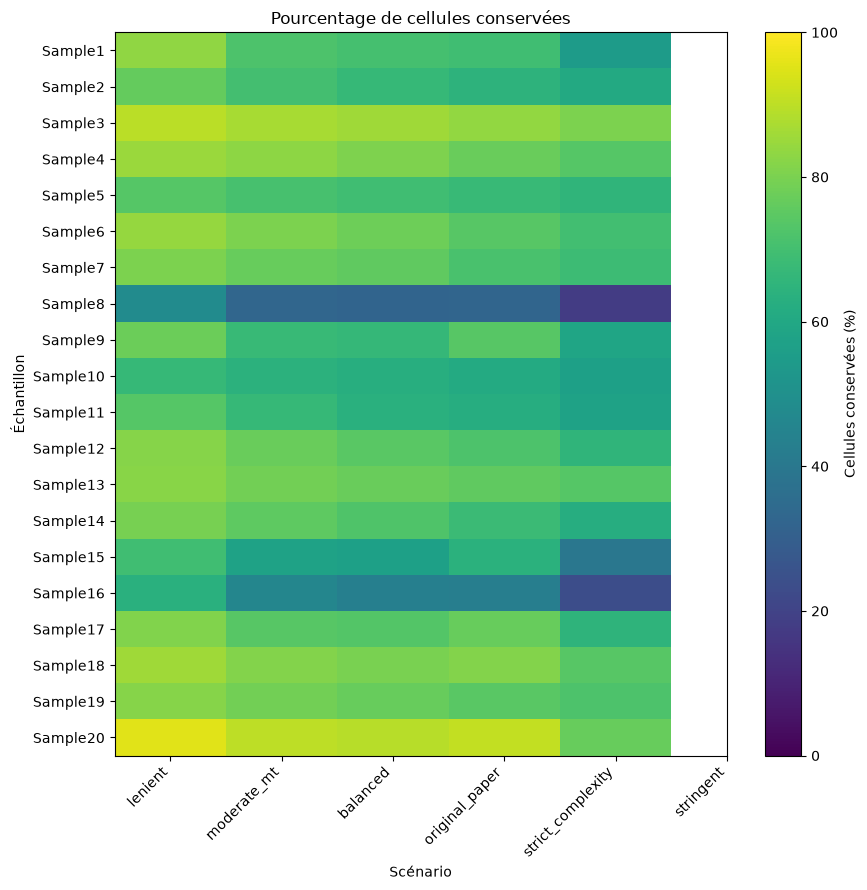

In [28]:
fig, ax = plt.subplots(figsize=(9, 9))
image = ax.imshow(sample_retention_matrix, aspect="auto", vmin=0, vmax=100, cmap="viridis")
ax.set_xticks(range(len(scenario_order)), scenario_order, rotation=45, ha="right")
ax.set_yticks(range(len(sample_order)), sample_order)
ax.set_xlabel("Scénario"); ax.set_ylabel("Échantillon")
ax.set_title("Pourcentage de cellules conservées")
fig.colorbar(image, ax=ax, label="Cellules conservées (%)")
fig.tight_layout()
fig.savefig(figure_dir / "qc_sensitivity_sample_retention_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

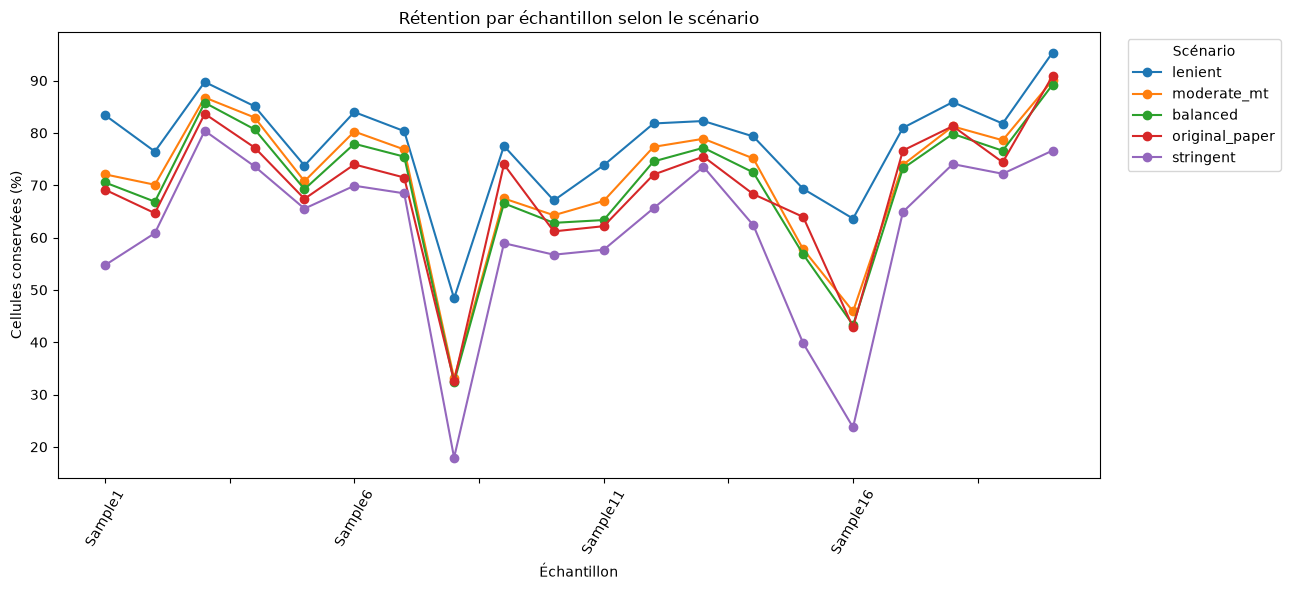

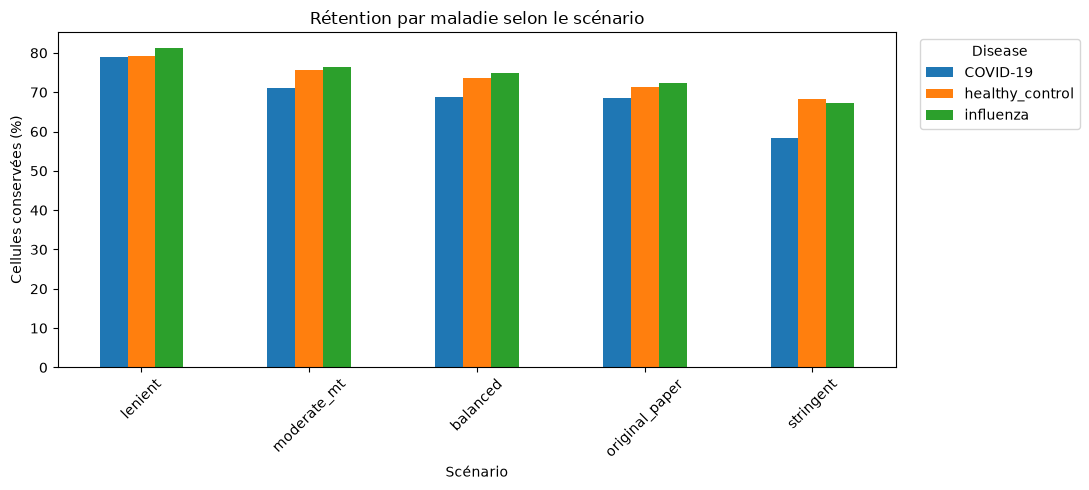

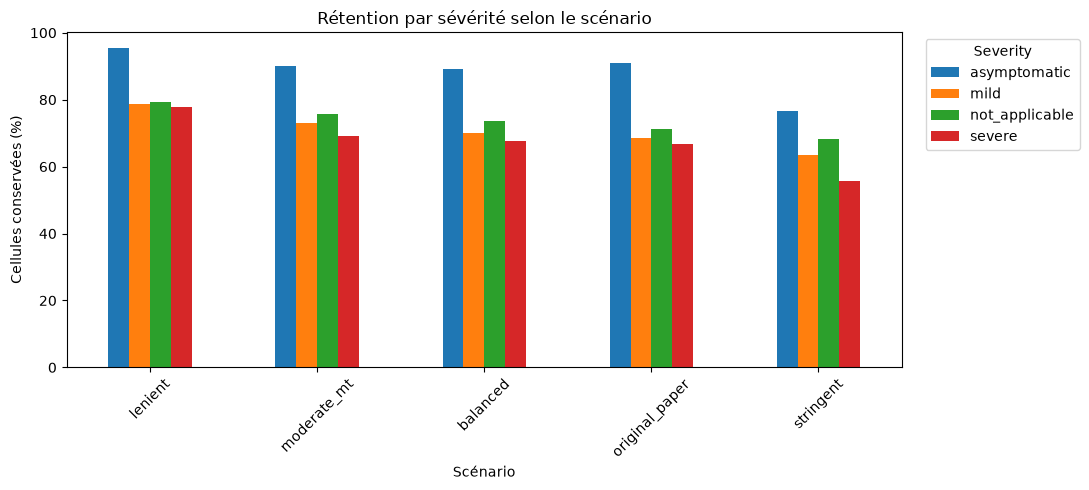

In [29]:
ax = sample_retention_matrix.plot(figsize=(13, 6), marker="o")
ax.set_xlabel("Échantillon"); ax.set_ylabel("Cellules conservées (%)")
ax.set_title("Rétention par échantillon selon le scénario")
ax.tick_params(axis="x", rotation=60)
ax.legend(title="Scénario", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.figure.tight_layout()
ax.figure.savefig(figure_dir / "qc_sensitivity_sample_retention.png", dpi=150, bbox_inches="tight")
plt.show()

disease_retention_matrix = disease_sensitivity_long.pivot(
    index="disease", columns="scenario", values="pct_retained"
).reindex(columns=display_scenarios)
ax = disease_retention_matrix.T.plot.bar(figsize=(11, 5))
ax.set_xlabel("Scénario"); ax.set_ylabel("Cellules conservées (%)")
ax.set_title("Rétention par maladie selon le scénario")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Disease", bbox_to_anchor=(1.02, 1), loc="upper left")
ax.figure.tight_layout()
ax.figure.savefig(figure_dir / "qc_sensitivity_disease_retention.png", dpi=150, bbox_inches="tight")
plt.show()

if severity_available:
    severity_retention_matrix = severity_sensitivity_long.pivot(
        index="severity", columns="scenario", values="pct_retained"
    ).reindex(columns=display_scenarios)
    ax = severity_retention_matrix.T.plot.bar(figsize=(11, 5))
    ax.set_xlabel("Scénario"); ax.set_ylabel("Cellules conservées (%)")
    ax.set_title("Rétention par sévérité selon le scénario")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(title="Severity", bbox_to_anchor=(1.02, 1), loc="upper left")
    ax.figure.tight_layout()
    ax.figure.savefig(figure_dir / "qc_sensitivity_severity_retention.png", dpi=150, bbox_inches="tight")
    plt.show()

## Application du scénario QC final

In [30]:
pass_qc = (
    (adata.obs["n_genes_by_counts"] >= 200)
    & (adata.obs["pct_counts_mt"] <= 15)
)
adata_qc = adata[pass_qc].copy()

In [31]:
n_cells_before_qc = adata.n_obs
n_cells_after_qc = adata_qc.n_obs
n_cells_removed_qc = n_cells_before_qc - n_cells_after_qc
pct_retained_qc = 100 * n_cells_after_qc / n_cells_before_qc

print("Cellules avant QC :", n_cells_before_qc)
print("Cellules après QC :", n_cells_after_qc)
print("Cellules éliminées :", n_cells_removed_qc)
print(f"Pourcentage conservé : {pct_retained_qc:.2f} %")
print("Nombre de gènes :", adata_qc.n_vars)
display(adata_qc.obs["sample_id"].value_counts().reindex(sample_order))
display(adata_qc.obs["disease"].value_counts())
display(adata_qc.obs[["n_genes_by_counts", "total_counts", "pct_counts_mt"]].describe())

Cellules avant QC : 85144
Cellules après QC : 59572
Cellules éliminées : 25572
Pourcentage conservé : 69.97 %
Nombre de gènes : 33538


sample_id
Sample1     4464
Sample2     4999
Sample3     4895
Sample4     1331
Sample5     4331
Sample6     2601
Sample7     1040
Sample8      652
Sample9      398
Sample10     714
Sample11    3978
Sample12    4526
Sample13    4646
Sample14    4490
Sample15    1502
Sample16    1873
Sample17    1345
Sample18    3239
Sample19    4123
Sample20    4425
Name: count, dtype: int64

disease
COVID-19           31463
healthy_control    17590
influenza          10519
Name: count, dtype: int64

,n_genes_by_counts,total_counts,pct_counts_mt
count,59572.000000,59572.000000,59572.000000
mean,1927.242261,6917.478027,7.305357
std,991.080555,5673.349121,2.778948
min,200.000000,230.000000,0.000000
25%,1401.000000,3961.000000,5.504756
50%,1812.500000,5591.000000,7.093283
75%,2417.000000,8525.000000,8.954495
max,8212.000000,152409.000000,14.997165


In [32]:
final_qc_checks = {
    "expected_n_obs": adata_qc.n_obs == 59_572,
    "all_20_samples_represented": adata_qc.obs["sample_id"].nunique() == 20,
    "min_200_genes": bool((adata_qc.obs["n_genes_by_counts"] >= 200).all()),
    "max_15_pct_mt": bool((adata_qc.obs["pct_counts_mt"] <= 15).all()),
}
if not all(final_qc_checks.values()):
    raise AssertionError({name: passed for name, passed in final_qc_checks.items() if not passed})
print("Vérifications finales :", ", ".join(f"{name}=OK" for name in final_qc_checks))

Vérifications finales : expected_n_obs=OK, all_20_samples_represented=OK, min_200_genes=OK, max_15_pct_mt=OK


## Comparaison QC avant/après

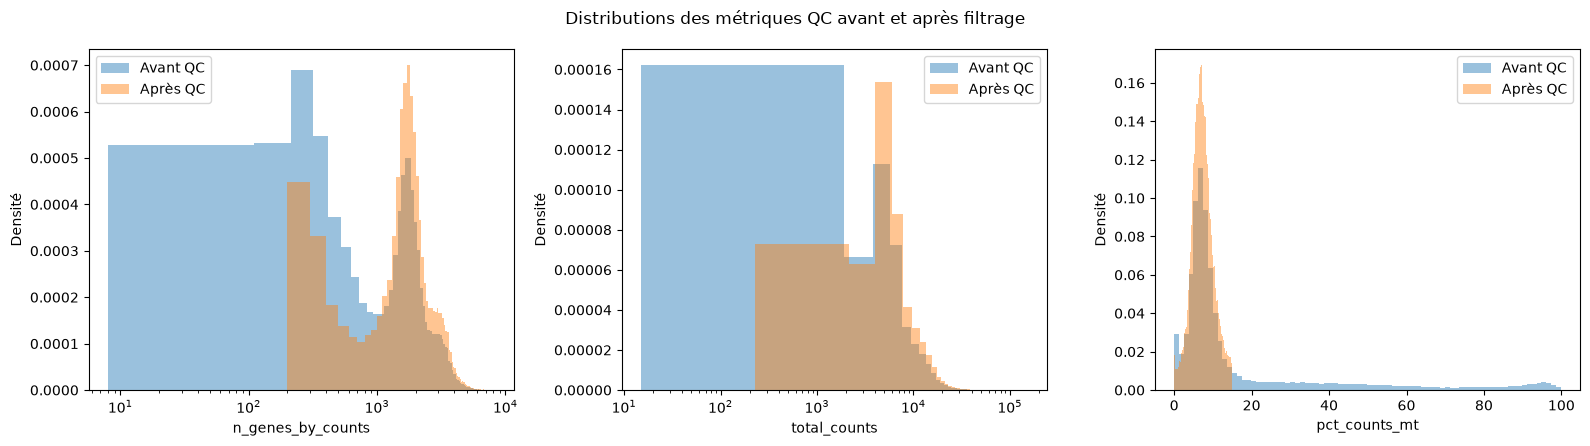

In [33]:
comparison_metrics = ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, metric in zip(axes, comparison_metrics):
    ax.hist(adata.obs[metric], bins=80, density=True, alpha=0.45, label="Avant QC")
    ax.hist(adata_qc.obs[metric], bins=80, density=True, alpha=0.45, label="Après QC")
    if metric in {"n_genes_by_counts", "total_counts"}:
        ax.set_xscale("log")
    ax.set_xlabel(metric)
    ax.set_ylabel("Densité")
    ax.legend()
fig.suptitle("Distributions des métriques QC avant et après filtrage")
fig.tight_layout()
fig.savefig(figure_dir / "qc_final_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

## Sauvegarde de l'objet QC

In [34]:
for dataframe in (adata_qc.obs, adata_qc.var):
    for column in dataframe.columns:
        if isinstance(dataframe[column].dtype, pd.StringDtype):
            dataframe[column] = dataframe[column].astype(object)
adata_qc.obs_names = pd.Index(adata_qc.obs_names.to_numpy(dtype=object))
adata_qc.var_names = pd.Index(adata_qc.var_names.to_numpy(dtype=object))

qc_output_path = "../data/processed/GSE149689_qc.h5ad"
adata_qc.write_h5ad(qc_output_path)
print("Objet QC sauvegardé :", qc_output_path)

Objet QC sauvegardé : ../data/processed/GSE149689_qc.h5ad


Les critères de QC ont été retenus après une analyse de sensibilité. Ils reproduisent les critères de l'étude originale et son effectif final de 59 572 cellules.